# Car Price Prediction with Machine Learning

**Objective:** Build and evaluate machine learning regression models to predict the selling price of used cars based on vehicle characteristics such as brand, age, fuel type, transmission, and mileage.

## 1. Import Required Libraries

In [1]:
# Core Libraries
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# Plot Style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Dataset Loading

In [2]:
# Load Dataset

data_path = "../data/car data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 301
Columns : 9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [5]:
display(df.describe(include="all"))

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


## 3. Initial Data Inspection

In [6]:
# Missing Values

missing_summary = df.isnull().sum().to_frame(name="Missing Values")

display(missing_summary)

,Missing Values
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
# Duplicate Records

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 2


In [8]:
# Column Names

list(df.columns)

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

### Observation

The dataset was successfully loaded and inspected. The initial review includes dataset dimensions, feature information, descriptive statistics, missing value analysis, and duplicate record identification. These checks help determine the preprocessing steps required before model development.

## 4. Data Cleaning and Feature Engineering

In [9]:
# Standardize Column Names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

display(df.columns)

Index(['car_name', 'year', 'selling_price', 'present_price', 'kms_driven',
       'fuel_type', 'seller_type', 'transmission', 'owner'],
      dtype='str')

In [10]:
# Standardize Categorical Values

categorical_columns = [
    "fuel_type",
    "seller_type",
    "transmission"
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.title()
    )

print("Categorical values standardized.")

Categorical values standardized.


In [11]:
# Remove Duplicate Records

records_before = len(df)

df = df.drop_duplicates()

records_after = len(df)

print(f"Records Before Cleaning : {records_before}")
print(f"Records After Cleaning  : {records_after}")
print(f"Duplicates Removed      : {records_before - records_after}")

Records Before Cleaning : 301
Records After Cleaning  : 299
Duplicates Removed      : 2


In [12]:
# Extract Brand Name

df["brand"] = df["car_name"].str.split().str[0]

display(df[["car_name", "brand"]].head())

,car_name,brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


In [13]:
# Create Car Age

CURRENT_YEAR = 2026

df["car_age"] = CURRENT_YEAR - df["year"]

display(df[["year", "car_age"]].head())

,year,car_age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [14]:
# Remove Original Year Column

df = df.drop(columns=["year"])

display(df.head())

,car_name,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,brand,car_age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,ritz,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,sx4,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,ciaz,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,wagon,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,swift,12


In [15]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Rows    : 299
Columns : 10


,car_name,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,brand,car_age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,ritz,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,sx4,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,ciaz,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,wagon,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,swift,12


### Observation

The dataset was cleaned by standardizing column names, formatting categorical values consistently, and removing duplicate records. Feature engineering introduced two new predictive variables: **Brand**, extracted from the car name, and **Car Age**, calculated from the manufacturing year. The original year column was removed after deriving the age feature, resulting in a cleaner dataset for analysis and model development.

## 5. Exploratory Data Analysis

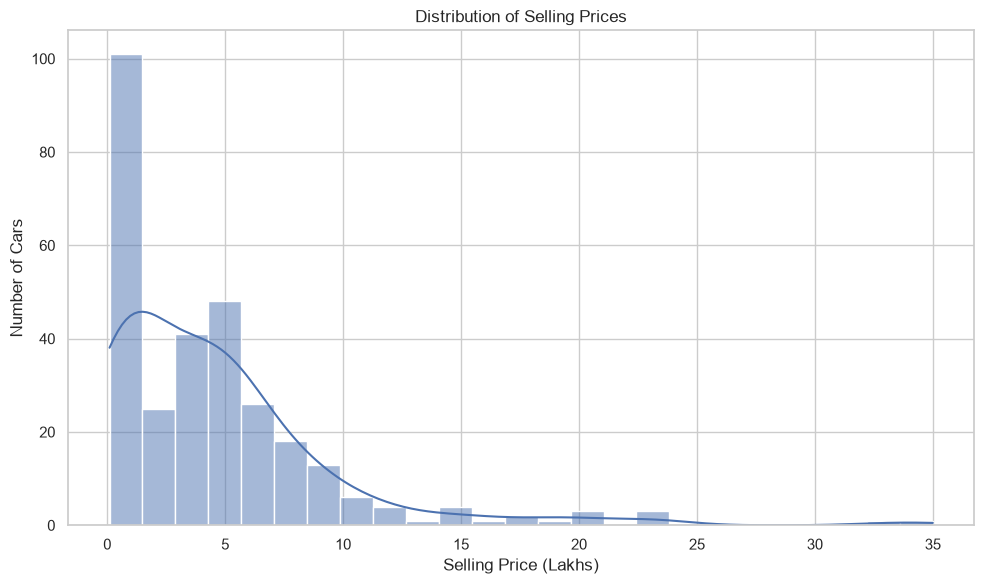

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="selling_price",
    bins=25,
    kde=True
)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../outputs/images/selling_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The selling price distribution shows that most used cars are concentrated in the lower price range, while comparatively fewer vehicles are available at higher prices. This indicates a positively skewed distribution.

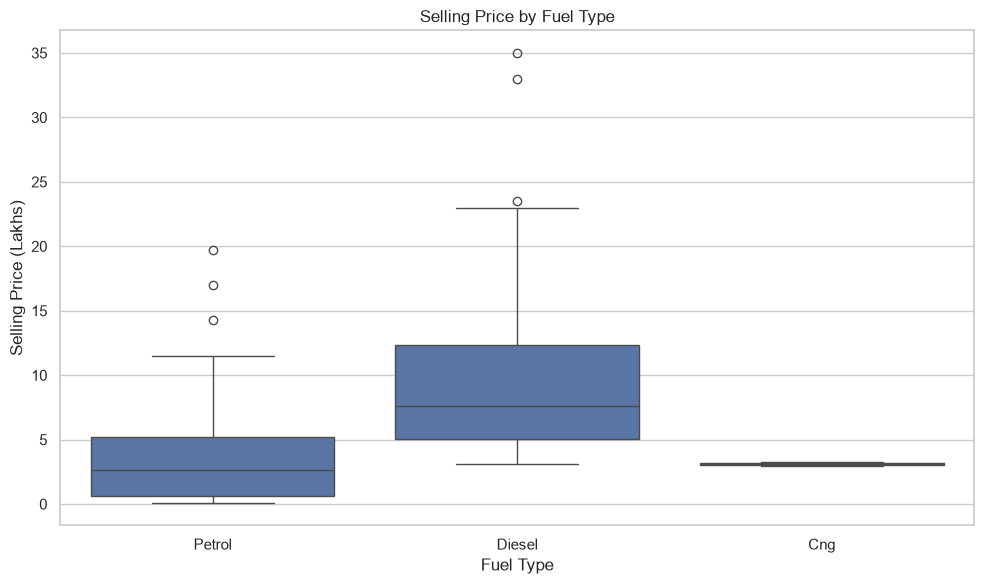

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="fuel_type",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")

plt.tight_layout()

plt.savefig(
    "../outputs/images/price_vs_fuel_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The box plot compares selling prices across different fuel types. It highlights variations in median prices, price ranges, and potential outliers for Petrol, Diesel, and CNG vehicles.

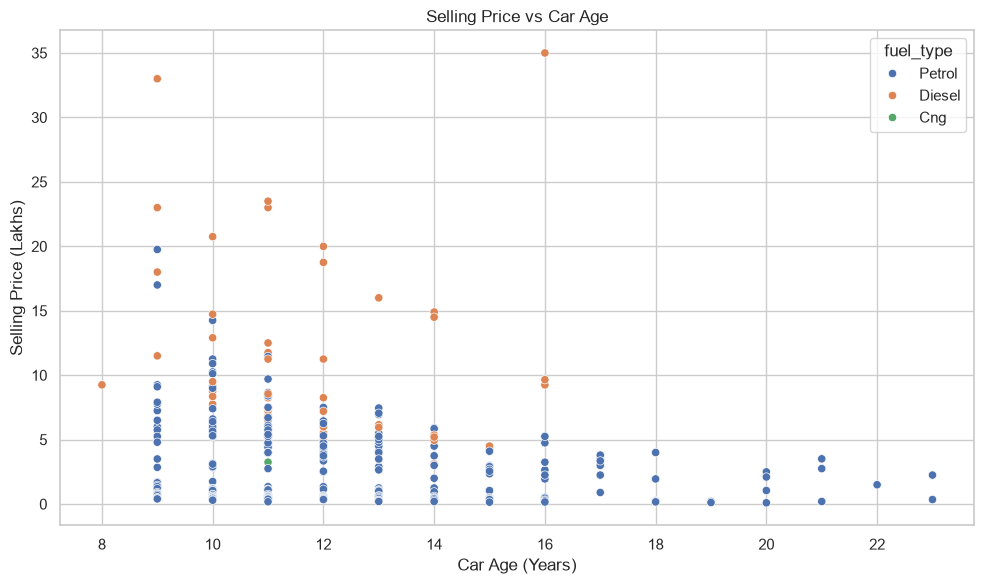

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price",
    hue="fuel_type"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")

plt.tight_layout()

plt.savefig(
    "../outputs/images/price_vs_car_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The scatter plot indicates that selling prices generally decrease as vehicle age increases. However, premium vehicles retain higher resale values even after several years.

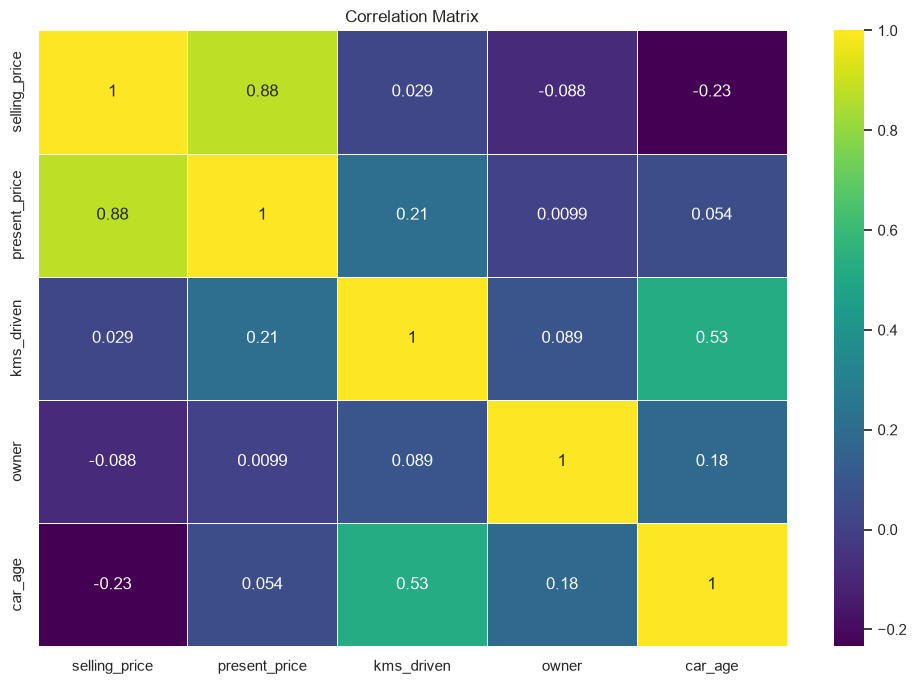

In [19]:
numeric_df = df.select_dtypes(include=["number"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../outputs/images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The correlation matrix illustrates relationships among numerical variables. Strong positive and negative correlations provide insight into which features may contribute most effectively to predicting the selling price.

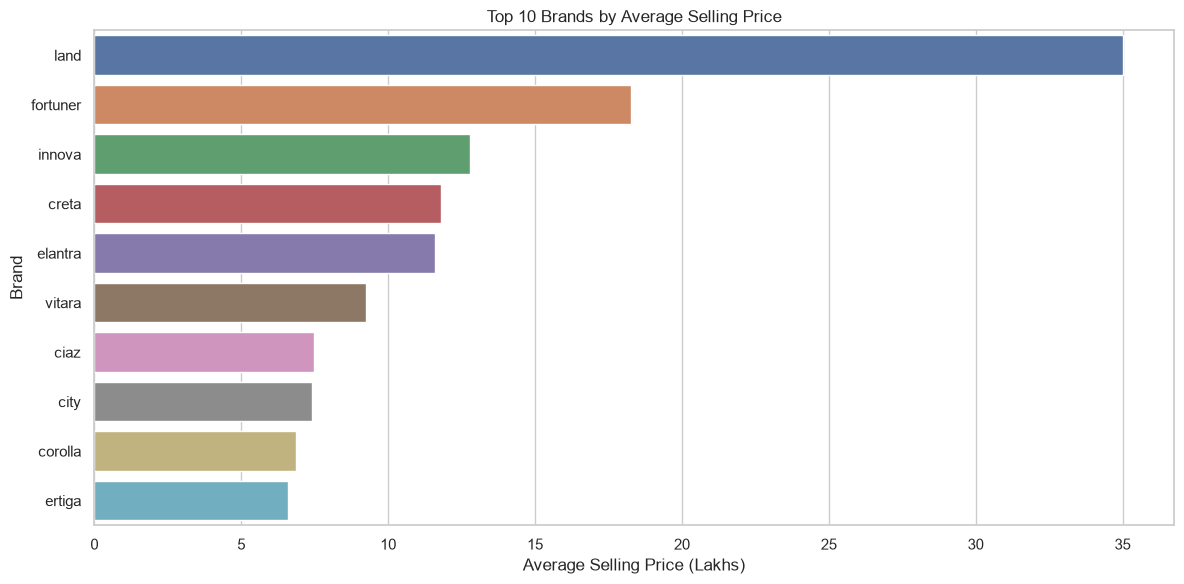

In [20]:
top_brands = (
    df.groupby("brand")["selling_price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_brands,
    x="selling_price",
    y="brand",
    hue="brand",
    legend=False
)

plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price (Lakhs)")
plt.ylabel("Brand")

plt.tight_layout()

plt.savefig(
    "../outputs/images/top_brands.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The chart highlights the average resale value of different car brands. Brands positioned at the top generally maintain stronger resale values due to market demand, reliability, and brand reputation.